# Superstore Sales Performance & Profitability Analysis
## Data Analytics Portfolio Project

### Project Overview
This notebook presents an end-to-end exploratory data analysis (EDA) on retail transaction data from a Superstore. The objective is to identify key operational insights, evaluate fulfillment efficiencies, analyze regional market dynamics, detect product-level profitability patterns, and investigate specific margin-draining anomalies. 

### Key Business Metrics Explored:
1. **Operational Efficiency:** Evaluating fulfillment velocities across various shipping modes.
2. **Geographical Dynamics:** Analyzing regional distributions of revenue, discounts, and bottom-line profit.
3. **Product Health:** Isolating highly lucrative categories from structurally unprofitable segments.
4. **Customer Behavior:** Analyzing top-tier contributors and identifying high-revenue, negative-margin outliers.

---
## 1. Environment Setup & Data Ingestion

In [1]:
import pandas as pd
df = pd.read_csv(r"E:\All My Study\Data Analytics Projects\Sales Performance Dashboard\01 data\Project_1_Superstore\Superstore_Cleaning_csv.csv")


### Visualizing Raw Records
We begin by displaying the first few rows of the dataset to verify successful ingestion and inspect the general structure, formatting, and granularity of the individual transactions.

In [2]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,43,CA-2016-101343,17-07-2016,22-07-2016,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Los Angeles,...,90049,West,OFF-ST-10003479,Office Supplies,Storage,"Eldon Base for stackable storage shelf, platinum",77.88,2,0.0,3.8940
1,514,CA-2017-163405,21-12-2017,25-12-2017,Standard Class,BN-11515,Bradley Nguyen,Consumer,United States,Los Angeles,...,90049,West,OFF-AR-10003811,Office Supplies,Art,Newell 327,6.63,3,0.0,1.7901
2,515,CA-2017-163405,21-12-2017,25-12-2017,Standard Class,BN-11515,Bradley Nguyen,Consumer,United States,Los Angeles,...,90049,West,OFF-AR-10001246,Office Supplies,Art,Newell 317,5.88,2,0.0,1.7052
3,1606,US-2016-115819,19-04-2016,24-04-2016,Second Class,JO-15280,Jas O'Carroll,Consumer,United States,Los Angeles,...,90049,West,OFF-AR-10000823,Office Supplies,Art,Newell 307,5.46,3,0.0,1.5288
4,1607,US-2016-115819,19-04-2016,24-04-2016,Second Class,JO-15280,Jas O'Carroll,Consumer,United States,Los Angeles,...,90049,West,OFF-AR-10004456,Office Supplies,Art,Panasonic KP-4ABK Battery-Operated Pencil Shar...,73.20,5,0.0,21.2280


### Structural Scale
Checking the overall dimensions of the dataset to determine the total number of records (rows) and transaction attributes (columns) available for analysis.

In [3]:
df.shape

(9994, 21)

### Data Schema and Completeness Evaluation
We run an inspection on data types (`dtypes`) and check for null values across all columns to confirm structural health and determine if any feature-specific data cleansing is required.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub_category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

### Baseline Distribution Statistics
Generating descriptive summary statistics (mean, median, standard deviation, and range limits) for numerical features such as Sales, Quantity, Discount, and Profit to identify raw distributions and detect obvious data skewness.

In [5]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 2. Data Cleaning & Feature Engineering

### Temporal Optimization
The preliminary inspection showed that temporal features like `order_date` and `ship_date` were ingested as generic object/string text. We convert them into robust Pandas `datetime64` objects to enable precise chronological sorting, delta calculations, and trend analysis.

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'], format="%d-%m-%Y", dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], format="%d-%m-%Y", dayfirst=True)

### Verifying Successful Feature Recasting
Re-running a concise schema check to verify that both date elements have transitioned successfully to appropriate datetime structures.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   str           
 2   order_date     9994 non-null   datetime64[us]
 3   ship_date      9994 non-null   datetime64[us]
 4   ship_mode      9994 non-null   str           
 5   customer_id    9994 non-null   str           
 6   customer_name  9994 non-null   str           
 7   segment        9994 non-null   str           
 8   country        9994 non-null   str           
 9   city           9994 non-null   str           
 10  state          9994 non-null   str           
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   str           
 13  product_id     9994 non-null   str           
 14  category       9994 non-null   str           
 15  sub_category   9994 non-null   s

### Feature Engineering: Calculating Order-to-Ship Cycle Times
To assess operational performance, we construct a new performance indicator—`shipping_days`—defined mathematically as:
\text{Shipping Days} = \text{Ship Date} - \text{Order Date}$$
This tells us exactly how long a package spends between order placement and logistical fulfillment.

In [8]:
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

### Targeted Row Inspection
Isolating the newly engineered feature alongside its base attributes to guarantee the arithmetic logic was correctly executed.

In [9]:
df[['order_date', 'ship_date', 'shipping_days']].head()

,order_date,ship_date,shipping_days
0,2016-07-17,2016-07-22,5
1,2017-12-21,2017-12-25,4
2,2017-12-21,2017-12-25,4
3,2016-04-19,2016-04-24,5
4,2016-04-19,2016-04-24,5


### Global Logistical Mean
Calculating the global average turnaround time across all store historical records to establish a macro baseline for delivery duration.

In [10]:

df['shipping_days'].mean()

np.float64(3.958174904942966)

### Evaluating Cycle Time Variance
Reviewing the dispersion metrics for order processing speeds to find the maximum delays and identify potential operational backlogs.

In [11]:
df['shipping_days'].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: shipping_days, dtype: float64

## 3. Operational Logistical Analysis

### Fulfillment Performance by Class
Grouping the calculated cycle times by `ship_mode` to check if shipping speeds match their service tiers (e.g., confirming Same Day or First Class options are outperforming standard methods).

In [12]:
df.groupby('ship_mode')['shipping_days'].mean()

ship_mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: shipping_days, dtype: float64

### Ordered Fulfillment Ranking
Sorting the delivery performance averages chronologically to easily rank fulfillment classes from fastest to slowest.

In [13]:
df.groupby('ship_mode')['shipping_days'].mean().sort_values()

ship_mode
Same Day          0.044199
First Class       2.182705
Second Class      3.238046
Standard Class    5.006535
Name: shipping_days, dtype: float64

### Visualizing Average Turnaround Times
We plot a bar chart comparing average shipping days across each service level to visually confirm fulfillment tier compliance.

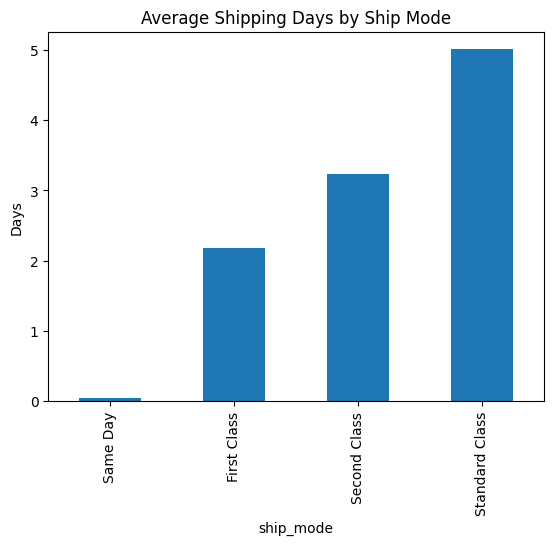

In [14]:
import matplotlib.pyplot as plt

shipping_avg = (df.groupby('ship_mode')['shipping_days'].mean().sort_values())

shipping_avg.plot(kind='bar')

plt.title('Average Shipping Days by Ship Mode')
plt.ylabel('Days')
plt.show()

## 4. Market & Regional Performance Deep-Dive

### Aggregate Revenue Distribution by Market Region
We calculate total sales across major geographic regions to understand market share size and isolate the primary drivers of topline growth.

In [15]:
df.groupby('region')['sales'].sum().sort_values(ascending=False)

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

### Visualizing Regional Market Contributions
Plotting a clean bar visualization to emphasize revenue disparities between different geographical regions.

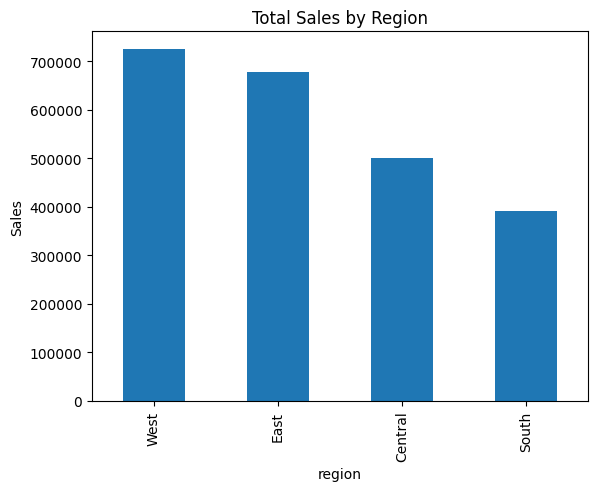

In [16]:
import matplotlib.pyplot as plt

region_sales = (df.groupby('region')['sales'].sum().sort_values(ascending=False))

region_sales.plot(kind='bar')

plt.title('Total Sales by Region')
plt.ylabel('Sales')
plt.show()


### Profitability vs. Revenue Multi-Axis Check
Topline sales do not always translate to bottom-line profitability. Here, we analyze regional `sales` alongside net `profit` to spot markets with high volumes but compressed margins.

In [17]:
df.groupby('region')[['sales', 'profit']].sum().round(2).sort_values('profit', ascending=False)

,sales,profit
region,,
West,725457.82,108418.45
East,678781.24,91522.78
South,391721.90,46749.43
Central,501239.89,39706.36


### Auditing Regional Promotional Schemes
To explain margin discrepancies across territories, we calculate the mean promotional discount rate applied within each geographic zone.

In [18]:
df.groupby('region')['discount'].mean().round(3).sort_values(ascending=False)

region
Central    0.240
South      0.147
East       0.145
West       0.109
Name: discount, dtype: float64

### Correlation Between High Discounts and Margin Compression
By evaluating mean discount strategies directly alongside average net profit metrics across regions, we can check if aggressive price-cutting is hurting net profitability.

In [19]:
df.groupby('region')[['discount', 'profit']].mean().round(3).sort_values('discount', ascending=False)

,discount,profit
region,,
Central,0.240,17.093
South,0.147,28.858
East,0.145,32.136
West,0.109,33.849


### Percentage Normalization
Converting the raw promotional averages into clear percentage values ($\%$) to present to stakeholders and leadership teams.

In [20]:
(df.groupby('region')['discount'].mean() * 100).round(1)

region
Central    24.0
East       14.5
South      14.7
West       10.9
Name: discount, dtype: float64

## 5. Product Category & Inventory Diagnostics

### Baseline Category Performance Evaluations
Shifting from geographic to inventory dimensions, we summarize overall sales and profits across core product categories (`Technology`, `Furniture`, `Office Supplies`) to uncover the core profit engines of the business.

In [21]:
df.groupby('category')[['sales', 'profit']].sum().round(2).sort_values('profit', ascending=False)

,sales,profit
category,,
Technology,836154.03,145454.95
Office Supplies,719047.03,122490.80
Furniture,741999.80,18451.27


### Visualizing Net Category Profit
Generating a category chart to emphasize bottom-line contribution differences across product categories.

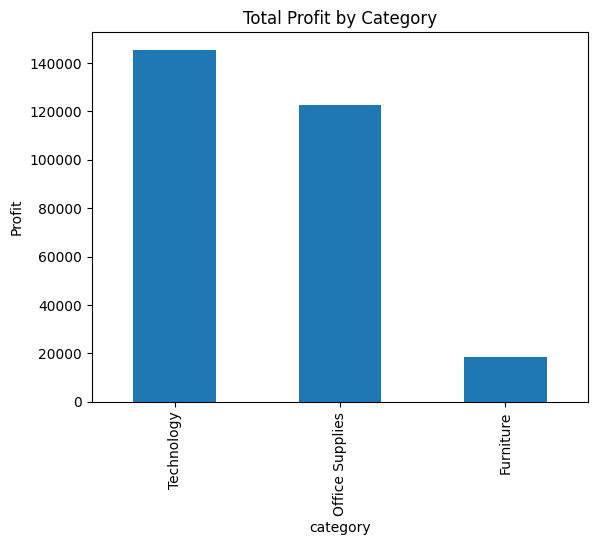

In [22]:
import matplotlib.pyplot as plt

category_profit = (
    df.groupby('category')['profit']
      .sum()
      .sort_values(ascending=False)
)

category_profit.plot(kind='bar')

plt.title('Total Profit by Category')
plt.ylabel('Profit')
plt.show()

### Granular Sub-Category Auditing
Expanding our analysis to specific product lines (`sub_category`) to identify highly profitable products and flag items causing significant operational losses.

In [23]:
df.groupby('sub_category')[['sales', 'profit']].sum().round(2).sort_values('profit')

,sales,profit
sub_category,,
Tables,206965.53,-17725.48
Bookcases,114880.00,-3472.56
Supplies,46673.54,-1189.10
Fasteners,3024.28,949.52
Machines,189238.63,3384.76
Labels,12486.31,5546.25
Art,27118.79,6527.79
Envelopes,16476.40,6964.18
Furnishings,91705.16,13059.14


## 6. Targeted Deep Dives into Margin Leakage

### Case Study: The "Tables" Sub-Category Margin Crisis
The sub-category analysis revealed that **Tables** are causing substantial financial losses despite generating healthy sales volume. We run a diagnostic summary on this segment to evaluate pricing, volume, and discount structures.

In [24]:
df[df['sub_category'] == 'Tables'][['sales','profit','discount']].describe().round(2).sort_values('discount', ascending=False)


,sales,profit,discount
count,319.00,319.00,319.00
max,4297.64,629.01,0.50
75%,872.17,33.85,0.40
50%,447.84,-31.37,0.30
mean,648.79,-55.57,0.26
25%,244.01,-122.83,0.20
std,615.77,230.57,0.17
min,24.37,-1862.31,0.00


### Isolating Table Vulnerabilities by Region
Grouping table performance by region to pinpoint whether the table profitability issue is systemic nationwide or confined to specific regional markets.

In [25]:
df[df['sub_category'] == 'Tables'].groupby('region')[['sales','profit']].sum().round(2).sort_values('profit', ascending=True)

,sales,profit
region,,
East,39139.81,-11025.38
South,43916.19,-4623.06
Central,39154.97,-3559.65
West,84754.56,1482.61


### Investigating Table Discount Metrics
Analyzing the relationship between average table discounts and regional profitability to determine if promotional markdown strategies are the root cause of the losses.

In [26]:
df[df['sub_category'] == 'Tables'].groupby('region')[['discount','profit']].mean().round(2).sort_values('discount', ascending=False)

,discount,profit
region,,
East,0.37,-137.82
Central,0.26,-49.44
South,0.22,-90.65
West,0.20,12.78


### Identifying Profitability Thresholds by Discount Level
Grouping net profits by specific discount levels to determine the exact discount threshold where selling tables becomes unprofitable.

In [27]:
df[df['sub_category'] == 'Tables'].groupby('discount')['profit'].mean().round(2).sort_values(ascending=False)

discount
0.00    184.39
0.20     -4.28
0.30    -63.01
0.40   -215.83
0.45   -226.65
0.50   -239.32
Name: profit, dtype: float64

## 7. Temporal Trends & Seasonality Analysis

### Macro Corporate Velocity (Year-over-Year Growth Trajectories)
Aggregating historical metrics by calendar year to evaluate business growth velocity and check if sales and profits are scaling proportionally over time.

In [28]:
df.groupby(df['order_date'].dt.year)[['sales','profit']].sum().round(2).sort_values('profit', ascending=False)

,sales,profit
order_date,,
2017,733215.26,93439.27
2016,609205.60,81795.17
2015,470532.51,61618.60
2014,484247.50,49543.97


### Plotting Historical Financial Trajectories
Generating a dual line plot to evaluate annual business velocity and ensure profit expansion is keeping pace with top-line sales growth.

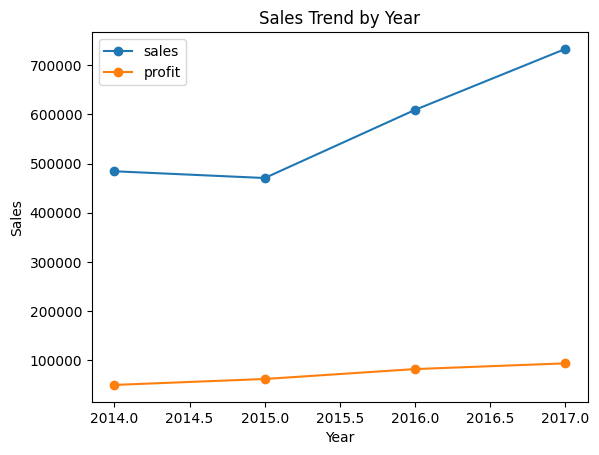

In [29]:
import matplotlib.pyplot as plt

yearly_sales = df.groupby(df['order_date'].dt.year)[['sales','profit']].sum().round(2).sort_values('profit', ascending=False)

yearly_sales.plot(kind='line', marker='o')

plt.title('Sales Trend by Year')
plt.ylabel('Sales')
plt.xlabel('Year')
plt.show()

## 8. Customer Profile Analytics & Outlier Audits

### Top 10 High-Value Enterprise Accounts by Revenue Volume
Isolating the top ten customers by gross revenue volume to identify the company's largest demand drivers.

In [30]:
df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

customer_name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64

### Top 10 Accounts by Net Profit Contribution
Isolating the top ten customers by net profit to evaluate client quality. We check if our highest-revenue accounts are also our most profitable ones.

In [31]:
df.groupby('customer_name')['profit'].sum().sort_values(ascending=False).head(10)

customer_name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: profit, dtype: float64

### Outlier Analysis: Auditing the Account of "Sean Miller"
The client review revealed an anomaly: **Sean Miller** is a top revenue-generating customer but ranks among the least profitable. We run an audit on all transactions associated with this account to uncover the source of this margin leakage.

In [32]:
df[df['customer_name'] == 'Sean Miller'][['sales','profit','discount']].describe().round(2)

,sales,profit,discount
count,15.00,15.00,15.00
mean,1669.54,-132.05,0.25
std,5807.09,467.12,0.18
min,3.49,-1811.08,0.00
25%,14.45,-8.56,0.20
50%,30.77,3.80,0.20
75%,324.40,7.78,0.20
max,22638.48,31.59,0.70


### Segmenting the Account Leakage by Product Category
Grouping Sean Miller's transactions by product category to determine whether his negative margin footprint spans his entire purchasing history or is isolated to a specific product group.

In [33]:

df[df['customer_name'] == 'Sean Miller'].groupby('category')[['sales','profit','discount']].sum().round(2)

,sales,profit,discount
category,,,
Furniture,679.57,54.96,0.4
Office Supplies,881.97,-211.99,2.1
Technology,23481.51,-1823.70,1.2


## 9. Intra-Year Seasonality Explorations

### Monthly Aggregation Matrix
Extracting the month component from order dates to evaluate business seasonality trends and locate peak sales periods throughout the calendar year.

In [34]:
df['month'] = df['order_date'].dt.month_name()

monthly_sales = (df.groupby('month')['sales'].sum().sort_values(ascending=False))

monthly_sales

month
November     352461.0710
December     325293.5035
September    307649.9457
March        205005.4888
October      200322.9847
August       159044.0630
May          155028.8117
June         152718.6793
July         147238.0970
April        137762.1286
January       94924.8356
February      59751.2514
Name: sales, dtype: float64

### Plotting the Chronological Sales Wave
Mapping monthly sales to a chronological timeline from January to December to visually highlight seasonal spikes, holiday demand surges, and quarterly cyclic behaviors.

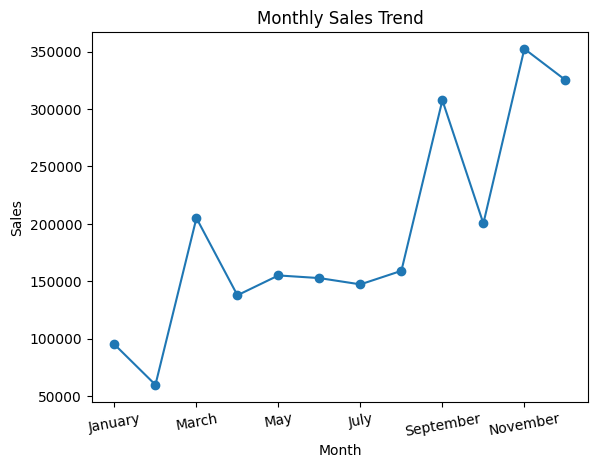

In [35]:
import matplotlib.pyplot as plt

month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_sales = (
    df.groupby('month')['sales']
      .sum()
      .reindex(month_order)
)

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.xlabel('Month')
plt.xticks(rotation=10)
plt.yticks(rotation=0)

plt.show()

## 10. Statistical Explorations & Advanced Variable Mapping

### Feature Correlation Matrix
Constructing a Pearson Correlation Matrix between key transaction variables (`sales`, `profit`, `discount`, and `quantity`) to quantify the strength and direction of linear relationships between numerical drivers.

In [36]:
df[['sales', 'profit', 'discount', 'quantity']].corr().round(2)

,sales,profit,discount,quantity
sales,1.00,0.48,-0.03,0.20
profit,0.48,1.00,-0.22,0.07
discount,-0.03,-0.22,1.00,0.01
quantity,0.20,0.07,0.01,1.00


### Distribution Analysis: Discount vs. Net Margin
Using a scatter plot to map the interaction between discounts and transaction-level profitability, illustrating how margin distribution shifts as promotional rates increase.

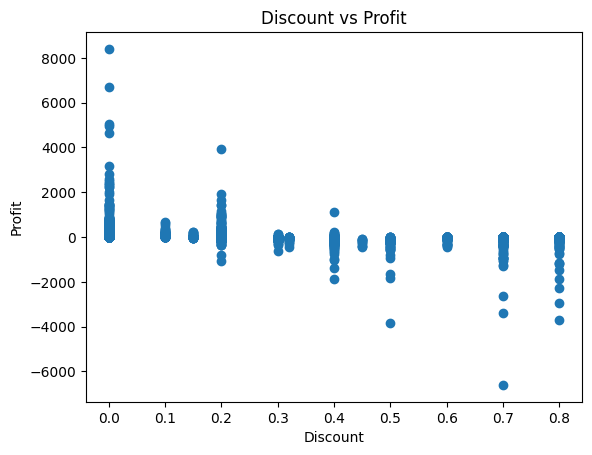

In [37]:
import matplotlib.pyplot as plt

plt.scatter(df['discount'], df['profit'])

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

### Executive Summary: Ranking Bottom-Line Profit Contribution by Sub-Category
We conclude our exploratory analysis with a horizontal summary chart that ranks all 17 product sub-categories by total profitability. This provides actionable insights for leadership teams to optimize inventory strategies, adjust pricing structures, and manage promotional guardrails.

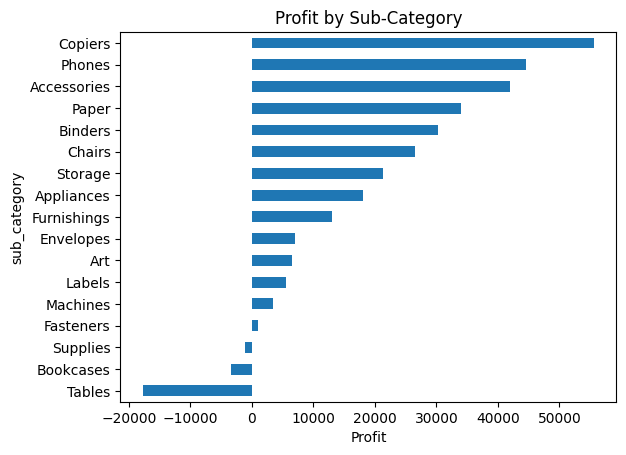

In [38]:
subcategory_profit = (
    df.groupby('sub_category')['profit']
      .sum()
      .sort_values()
)

subcategory_profit.plot(kind='barh')

plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.show()